<a href="https://colab.research.google.com/github/TKhahahah/Data_Mining_FinalProject/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [149]:
%pip install torch_geometric

## Library Version 22_4 : Dropout between later, Dense graphs, USe Otograohic precitaiton edges caled from U, W CW, Dem and leedside windside, AttentionLSTM_V8, No Quantile Mapping, adaptive_huber_loss with percentile_loss to handle Extreme Events. Input includes calculated indices: PDO, ONI, SWM, DMI, and downloaded indices: MEIV2, BSISO, and MJO. , NEW NE index


In [150]:
import os
import pandas as pd
import numpy as np
import sys
import datetime
import copy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import random
import matplotlib.pyplot as plt
import copy
from dateutil.relativedelta import relativedelta
import time
import inspect
import time as countdown
from tqdm import tqdm
import time as countdown
from torch_geometric.data import HeteroData




import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
from torch.nn import Parameter
from torch import Tensor


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [151]:

import os, sys

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Hyperparameters

In [152]:
algo='LSTM_V23_11'

num_epoch = 300
window_size = 24  #Window size
horizon = 12   #Prediction horizon
TBPTT_K = 24

learn_rate =0.001
weight_decay =1e-4
cluster =7 #choose cluster of the HII stations
k_fold_num=2
percentile_loss =0.95

# PARAMETERS FOR SMALL DATA
noise_level = 0.05  # Standard deviation of noise (5% of signal)

min_epochs = 20
patience = 100
LOG_EVERY = 20


hidden_size_list =[128]
num_layers_list =[2]
drop_out_list=[0.4]



## Load dataset

In [153]:
X_index = pd.read_csv('/content/drive/MyDrive/KKU3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU3/Y_variable(Rainfall).csv')
# Convert 'DATE' column in Y_df to datetime objects if it's not already
X_index['DATE'] = pd.to_datetime(X_index['DATE'])

# Format the dates in Y_df as 'YYYY-MM-01'
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')



node = pd.read_csv('/content/drive/MyDrive/KKU3/Node_table_TMD.csv')


path_feature = os.path.join("/content/drive/MyDrive/KKU3/lookup_table_reanalysis_v5.csv")
feature = pd.read_csv(path_feature, header= "infer")



In [154]:
Y_rainfall = Y_rainfall.rename(columns={'code': 'Node'})

Y_rainfall_clean = Y_rainfall.copy()
num_feature = len(feature[feature['Cluster']==cluster])

In [155]:

def apply_time_lag(df, column_name, lag):
    # Create a new column name with the lag suffix
    new_column_name = f"{column_name}_lag{lag}"

    # Shift the column values by the specified lag
    df[new_column_name] = df[column_name].shift(lag)

    return df

# Define the time lags for each climate index

time_lags = {

    'MEIV2': [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE': [1],
    'PDO': [1, 2],
    'ONI': [1, 2],
    'DMI': [1, 2],
    'BSISO1': [1],
    'BSISO1-Phase': [1],
    'SWM': [1],

}




# Apply time lags to each specified column in df_merge_type
for column, lag in time_lags.items():
      if column in X_index.columns:
            for lag_item in lag:
                X_index = apply_time_lag(X_index, column, lag_item)
      else:
        print(f"Warning: Column '{column}' not found in df_merge_type. Skipping.")


Data cleansing

In [156]:
HQ_date_get_month_df  =  Y_rainfall.copy()
Y_rainfall_clean =  Y_rainfall.copy()
HQ_date_get_month_df['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for month in range(1, 12 + 1):
    # Filter the data for the current year
    HQ_data = HQ_date_get_month_df[HQ_date_get_month_df['DATE'] == month]

    # Average rainfall
    av_r = HQ_data.iloc[:, 1:].median()

    # Create a dictionary to hold the data for this year
    month_dict = {'MONTH': month}
    month_dict.update(av_r)

    # Append the data for this year to the list
    month_avg_list.append(month_dict)

HQ_month_avg = pd.DataFrame(month_avg_list)

for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(0, len(Y_rainfall_clean)):
        if(np.isnan(Y_rainfall_clean.iloc[j, i])):
             Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[pd.to_datetime(Y_rainfall_clean.iloc[:, 0]).dt.month[j]-1, i]

In [157]:
Y_rainfall_clean['DATE'].max()

'2025-03-01'

In [158]:
start_training_date = '1982-01-01'


X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01
Maximum date possible :  2025-03-01 00:00:00


In [159]:
start_training_date = Y_rainfall_clean['DATE'].min()

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01 00:00:00
Maximum date possible :  2025-03-01 00:00:00


In [160]:
#Count null value of each indexs
print("Number of index columns which contain null value : ",len(X_index_interval_date.isnull().sum()[X_index_interval_date.isnull().sum()>0]), sep="")
print("Number of rainfall station which contain null value : ",len(Y_rainfall_interval_date.isnull().sum()[Y_rainfall_interval_date.isnull().sum()>0]), sep="")

Number of index columns which contain null value : 0
Number of rainfall station which contain null value : 0


## Convert DATE columns to index columns

In [161]:
def convert_columns_to_index_columns(df,col_name):
    df.loc[:,col_name] = pd.to_datetime(df[col_name])
    df = df.set_index(col_name, inplace=False)
    return df

- independend variable dataframe

In [162]:
X_index_df_ready = convert_columns_to_index_columns(X_index_interval_date, 'DATE')
Y_rainfall_df_ready = convert_columns_to_index_columns(Y_rainfall_interval_date, 'DATE')

In [163]:
print("nrow of X : {}".format(X_index_df_ready.shape[0]))
print("nrow of Y : {}".format(X_index_df_ready.shape[0]))

nrow of X : 519
nrow of Y : 519


## Standardize

In [164]:

#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()

X_normalize_data = scaler_X.fit_transform(X_index_df_ready)
X_index_normalized_df = pd.DataFrame(X_normalize_data, columns=X_index_df_ready.columns)

scaler_Y = StandardScaler()

Y_normalize_data = scaler_Y.fit_transform(Y_rainfall_df_ready)
Y_rainfall_normalized_df = pd.DataFrame(Y_normalize_data, columns=Y_rainfall_df_ready.columns)

In [165]:

# Save the scaler
with open('/content/drive/MyDrive/KKU3/scaler_Y.pkl', 'wb') as file:
    pickle.dump(scaler_Y, file)
# Save the scaler
with open('/content/drive/MyDrive/KKU3/scaler_X.pkl', 'wb') as file:
    pickle.dump(scaler_X, file)


# Load the scaler for inference
with open('/content/drive/MyDrive/KKU3/scaler_Y.pkl', 'rb') as file:
    scaler_Y = pickle.load(file)

## Summarises all climate index

In [166]:
#Get date range from original files because after normalization index will reset
og_date_range = X_index_interval_date['DATE']
X_index_normalized_df.set_index(og_date_range, inplace=True)
Y_rainfall_normalized_df.set_index(og_date_range, inplace=True)

n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  24
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1'],
      dtype='object')


## Add cos sin function to X

### Combine static feature

In [167]:
X_index_normalized_df['Month_sin'] = np.sin(2 * np.pi * X_index_normalized_df.index.month / 12)
X_index_normalized_df['Month_cos'] = np.cos(2 * np.pi * X_index_normalized_df.index.month / 12)

In [168]:
station_id_list = Y_rainfall_normalized_df.columns
list_table = []
for code_st in station_id_list:
  #print(code_st)

  #print(static_value)
  eindices_df = X_index_normalized_df.copy()



  eindices_df[code_st] = Y_rainfall_normalized_df[code_st]

  list_table.append(eindices_df)

In [169]:
n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  26
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1', 'Month_sin', 'Month_cos'],
      dtype='object')


## Split dataframe to add static feature

### Import meta data

### Add new date and latitude-longitude format columns

## Split training and testing

### Define start and end date of each interval

# Train Fold 1 = 2018-2020, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 2018-2022, Val = 2021-2023, Test = 1/2022 - 12/2024

In [170]:
#Train interval

start_interval_train1 =  pd.to_datetime(min(Y_rainfall_normalized_df.index))
#maximum_interval_train = max(Y_rainfall_normalized_df.index[0:-6])


end_interval_train1 = start_interval_train1 + relativedelta(months=37*12+11)


#Test1 interval
start_interval_val1 = start_interval_train1 + relativedelta(months=36*12)
end_interval_val1 =  start_interval_train1 + relativedelta(months=38*12+11)



#Test1 interval
start_interval_test1 = start_interval_train1 + relativedelta(months=37*12)
end_interval_test1 = start_interval_train1 + relativedelta(months=39*12+11)
#end_interval_test = start_interval_test + relativedelta(months=backward_months+17)
#Display
print("############################################################")
print("TRAINING Fold 1")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train1)

print("############################################################")
print("VALIDATION Fold 1")
print('Start interval date of testing set: ', start_interval_val1)
print('End interval date of testing set :', end_interval_val1)
print("############################################################")



print("############################################################")
print("TESTING Fold 1")
print('Start interval date of testing set: ', start_interval_test1)
print('End interval date of testing set :', end_interval_test1)
print("############################################################")
#if cluster in [4 ,5,6,7, 8,9 ,10,11,12]:
#    start_interval_train1 = start_interval_val1 +  relativedelta(months=1)

#    end_interval_train2 = start_interval_train1 +  relativedelta(months=4*12+12)


    #Train interval
#    start_interval_val2 = start_interval_train1 +  relativedelta(months=3*12-1)
#    end_interval_val2 = start_interval_train1 +  relativedelta(months=5*12+10)



    #Test2 interval
#    start_interval_test2 = start_interval_train1 +  relativedelta(months=3*12+9)
#    end_interval_test2 = start_interval_train1 +  relativedelta(months=6*12+11-3)

#else:
start_interval_train1 = start_interval_train1

end_interval_train2 = start_interval_train1 + relativedelta(months=40*12)


    #Train interval
start_interval_val2 = start_interval_train1  + relativedelta(months=39*12)
end_interval_val2 = start_interval_train1 + relativedelta(months=41*12+11)



    #Test2 interval
start_interval_test2 = start_interval_train1 + relativedelta(months=40*12)
end_interval_test2 = start_interval_train1 + relativedelta(months=42*12+11)


#Display
print("############################################################")
print("TRAINING Fold 2")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train2)

print("############################################################")
print("VALIDATION Fold 2")
print('Start interval date of testing set: ', start_interval_val2)
print('End interval date of testing set :', end_interval_val2)
print("############################################################")



print("############################################################")
print("TESTING Fold 2")
print('Start interval date of testing set: ', start_interval_test2)
print('End interval date of testing set :', end_interval_test2)
print("############################################################")

# Train Fold 1 = 1982-2019, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 1982-2022, Val = 2021-2023, Test = 2022 - 2024

############################################################
TRAINING Fold 1
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2019-12-01 00:00:00
############################################################
VALIDATION Fold 1
Start interval date of testing set:  2018-01-01 00:00:00
End interval date of testing set : 2020-12-01 00:00:00
############################################################
############################################################
TESTING Fold 1
Start interval date of testing set:  2019-01-01 00:00:00
End interval date of testing set : 2021-12-01 00:00:00
############################################################
############################################################
TRAINING Fold 2
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2022-01-01 00:00:00
############################################################
VALIDATION Fold 2
Start interval date of testing set:  2

### Split training and testing

In [171]:
#Split test and train

Train_df_list1, Val_df_list1, Test_df_list1,Train_df_list2,  Val_df_list2 ,Test_df_list2 = [], [],[],[],[],[]
for i_table in range(len(list_table)):
  Train_df_list1.append(list_table[i_table][start_interval_train1:end_interval_train1])
  Val_df_list1.append(list_table[i_table][start_interval_val1:end_interval_val1])
  Test_df_list1.append(list_table[i_table][start_interval_test1:end_interval_test1])
  Train_df_list2.append(list_table[i_table][start_interval_train1:end_interval_train2])
  Val_df_list2.append(list_table[i_table][start_interval_val2:end_interval_val2])
  Test_df_list2.append(list_table[i_table][start_interval_test2:end_interval_test2])

fold =[]
fold.append([Train_df_list1,Test_df_list1,Val_df_list1])
fold.append([Train_df_list2,Test_df_list2,Val_df_list2])


# Feature selection part

## Focus only feature of climate

In [172]:
print("The first feature size that is climate index:", n_feature_climate)

The first feature size that is climate index: 26


In [173]:
selected_index =[]
feature_cluster =  feature[feature['Cluster']==cluster]
for feature_index in range(len(feature_cluster)):
    for i in range(len(feature_climate)):
        if((feature_climate[i] == feature_cluster.iloc[feature_index,1]) and feature_cluster.iloc[feature_index,5] == 0):
                selected_index.append(i)

        elif(feature_cluster.iloc[feature_index,5] != 0):
            for i_lag in range(len(feature_climate)):
                if(feature_climate[i_lag] == feature_cluster.iloc[feature_index,1]+'_lag'+str(feature_cluster.iloc[feature_index,5])):
                    selected_index.append(i_lag)
                    break
                else:
                    continue  # Continue if the inner loop wasn't broken.
            break  # Inner loop was broken, break the outer.

selected_index.sort()
feature_climate[selected_index]


Index(['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin',
       'Month_cos'],
      dtype='object')

## Feature selection
- Create binary position (length = climate feature)

In [174]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [0, 0, 1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 24, 25, 28]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


## Select columns by position vector (position_all)

In [175]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 24, 25, 26]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


In [176]:
def select_feature_f(list_df,position_feature_index):
    for i in range(len(list_df)):
        list_df[i] = list_df[i].iloc[:,position_feature_index]
    return list_df

In [177]:
#Fold 1 = Fold[0] , Fold 2 = Fold[1]
#Test Fold 1 = Fold[0][0] , Train Fold 1 = Fold[0][1], Validation Fold 1 = Fold[0][2]
fold[0][0] = select_feature_f(list_df = fold[0][0], position_feature_index = position_all_index)
fold[0][1] = select_feature_f(list_df = fold[0][1], position_feature_index = position_all_index)
fold[0][2] = select_feature_f(list_df = fold[0][2], position_feature_index = position_all_index)
fold[1][0] = select_feature_f(list_df = fold[1][0], position_feature_index = position_all_index)
fold[1][1] = select_feature_f(list_df = fold[1][1], position_feature_index = position_all_index)
fold[1][2] = select_feature_f(list_df = fold[1][2], position_feature_index = position_all_index)

In [178]:
len(Y_rainfall_normalized_df.columns)

132

## Read node location

In [179]:
cluster_station= []
for index in range(0,len(Y_rainfall_normalized_df.columns)):
    if (node['quality'].iloc[index]==1 and node['cluster'].iloc[index]==cluster) :
            cluster_station.append(index)


In [180]:
for index in range(len(cluster_station)):
    print(node['Node'].iloc[cluster_station[index]])

300201
300202
303201
303301
327501
328201
331201
331301
331401


Create node

Creat training test set for each station

Create static features

In [181]:
num_feature = len(feature[feature['Cluster']==cluster])

## Check edges

In [182]:

def extract_features(feature,j, window_size,horizon,data_list):
    xs_list= []
    for station in cluster_station:
        xs_new= np.array(data_list[station].iloc[:,feature][j:j+window_size])
        xs_list.append([xs_new])
    xs = np.array(xs_list)
    return xs

In [183]:
climate_name_list

['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']

# Linear Regression

In [184]:
# ============================================================
# STEP 1: สร้าง Dataset สำหรับ Linear Regression (Direct)
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

horizon_lr = 12   # Direct predict 12 เดือนพร้อมกัน
window_size = 24  # ใช้ค่าเดิม

def build_lr_dataset(data_list, station_idx):
    """
    สร้าง dataset แบบ sliding window
    X : (n_samples, window_size × n_features)
    y : (n_samples, horizon_lr)
    """
    df = data_list[station_idx]
    X_all, y_all = [], []

    for j in range(len(df) - window_size - horizon_lr + 1):
        x_window = df.iloc[j : j + window_size].values          # (24, 8)
        y_target = df.iloc[j + window_size : j + window_size + horizon_lr, -1].values  # (12,)
        X_all.append(x_window.flatten())
        y_all.append(y_target)

    return np.array(X_all), np.array(y_all)

# ตรวจสอบ shape
st = cluster_station[0]
X_tr, y_tr = build_lr_dataset(fold[0][0], st)
X_te, y_te = build_lr_dataset(fold[0][1], st)
print("Train X:", X_tr.shape, "y:", y_tr.shape)
print("Test  X:", X_te.shape, "y:", y_te.shape)

Train X: (421, 192) y: (421, 12)
Test  X: (1, 192) y: (1, 12)


In [185]:
# ============================================================
# STEP 2: Train Linear Regression แยกทุกสถานี ทั้ง 2 Fold
# ============================================================

results = {}

for fold_idx in range(2):
    results[fold_idx] = {}
    train_list = fold[fold_idx][0]
    test_list  = fold[fold_idx][1]
    val_list   = fold[fold_idx][2]

    for station_idx in cluster_station:
        station_name = node['Node'].iloc[station_idx]

        # สร้าง dataset จาก train
        X_train, y_train = build_lr_dataset(train_list, station_idx)

        # train 12 โมเดล แยกทีละ horizon
        models_h = []
        for h in range(horizon_lr):
            m = LinearRegression()
            m.fit(X_train, y_train[:, h])
            models_h.append(m)

        # window สุดท้ายของ train → predict 12 เดือนถัดไป
        last_window = train_list[station_idx].values[-window_size:]  # (24, 8)
        x_input = last_window.flatten().reshape(1, -1)               # (1, 192)

        y_pred_test = np.array([models_h[h].predict(x_input)[0] for h in range(horizon_lr)])

        # val ใช้ window ช่วงต้นของ val set
        val_window = val_list[station_idx].values[:window_size]      # (24, 8)
        x_input_val = val_window.flatten().reshape(1, -1)            # (1, 192)

        y_pred_val = np.array([models_h[h].predict(x_input_val)[0] for h in range(horizon_lr)])

        # actual — ข้าม window แรก 24 เดือน → เอา 12 เดือนถัดไป
        y_test = test_list[station_idx].iloc[window_size : window_size + horizon_lr, -1].values
        y_val  = val_list[station_idx].iloc[window_size : window_size + horizon_lr,  -1].values

        # inverse transform กลับเป็น mm
        col_idx = station_idx

        def inverse_single(y_norm, col):
            dummy = np.zeros((len(y_norm), scaler_Y.n_features_in_))
            dummy[:, col] = y_norm
            return scaler_Y.inverse_transform(dummy)[:, col]

        results[fold_idx][station_name] = {
            'models'      : models_h,
            'y_test'      : inverse_single(y_test,      col_idx),
            'y_pred_test' : inverse_single(y_pred_test, col_idx),
            'y_val'       : inverse_single(y_val,       col_idx),
            'y_pred_val'  : inverse_single(y_pred_val,  col_idx),
            'test_dates'  : test_list[station_idx].index[window_size : window_size + horizon_lr],
            'val_dates'   : val_list[station_idx].index[window_size : window_size + horizon_lr],
        }

print("Training เสร็จสิ้น ✓")

Training เสร็จสิ้น ✓


In [186]:
# ============================================================
# STEP 3: คำนวณ Metrics ทุกสถานี ทั้ง 2 Fold (เพิ่ม NSE)
# ============================================================

def nse_score(y_true, y_pred):
    """Nash-Sutcliffe Efficiency"""
    numerator   = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    if denominator == 0:
        return np.nan
    return 1 - (numerator / denominator)

metric_rows = []

for fold_idx in range(2):
    for station_name, res in results[fold_idx].items():
        for split, y_true, y_pred in [
            ('Test', res['y_test'], res['y_pred_test']),
            ('Val',  res['y_val'],  res['y_pred_val']),
        ]:
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae  = mean_absolute_error(y_true, y_pred)
            r2   = r2_score(y_true, y_pred)
            nse  = nse_score(y_true, y_pred)

            metric_rows.append({
                'Fold'   : fold_idx + 1,
                'Station': station_name,
                'Split'  : split,
                'RMSE'   : round(rmse, 4),
                'MAE'    : round(mae,  4),
                'R²'     : round(r2,   4),
                'NSE'    : round(nse,  4),
            })

metrics_df = pd.DataFrame(metric_rows)
print(metrics_df.to_string(index=False))

print("\n=== ค่าเฉลี่ยแต่ละ Fold ===")
print(metrics_df.groupby(['Fold','Split'])[['RMSE','MAE','R²','NSE']].mean().round(4))

 Fold  Station Split     RMSE      MAE      R²     NSE
    1   300201  Test  63.2162  53.0331  0.5794  0.5794
    1   300201   Val  72.5813  52.4625  0.5419  0.5419
    1   300202  Test  87.3711  59.4261  0.1145  0.1145
    1   300202   Val  59.5766  46.5708  0.0810  0.0810
    1   303201  Test  60.3736  49.1123  0.7681  0.7681
    1   303201   Val  69.4883  57.6462  0.6579  0.6579
    1   303301  Test  64.6666  52.2675  0.6563  0.6563
    1   303301   Val  74.0877  59.1135  0.6386  0.6386
    1   327501  Test  62.2911  41.7964  0.2668  0.2668
    1   327501   Val  51.7088  39.9540  0.7989  0.7989
    1   328201  Test  55.7501  45.1209  0.6261  0.6261
    1   328201   Val  46.8401  40.0397  0.6814  0.6814
    1   331201  Test  56.3638  41.9760  0.4227  0.4227
    1   331201   Val  67.5787  52.0337  0.6841  0.6841
    1   331301  Test  62.7008  49.0655  0.1950  0.1950
    1   331301   Val  60.6029  52.5052  0.7013  0.7013
    1   331401  Test  97.5070  70.6618 -0.0667 -0.0667
    1   33

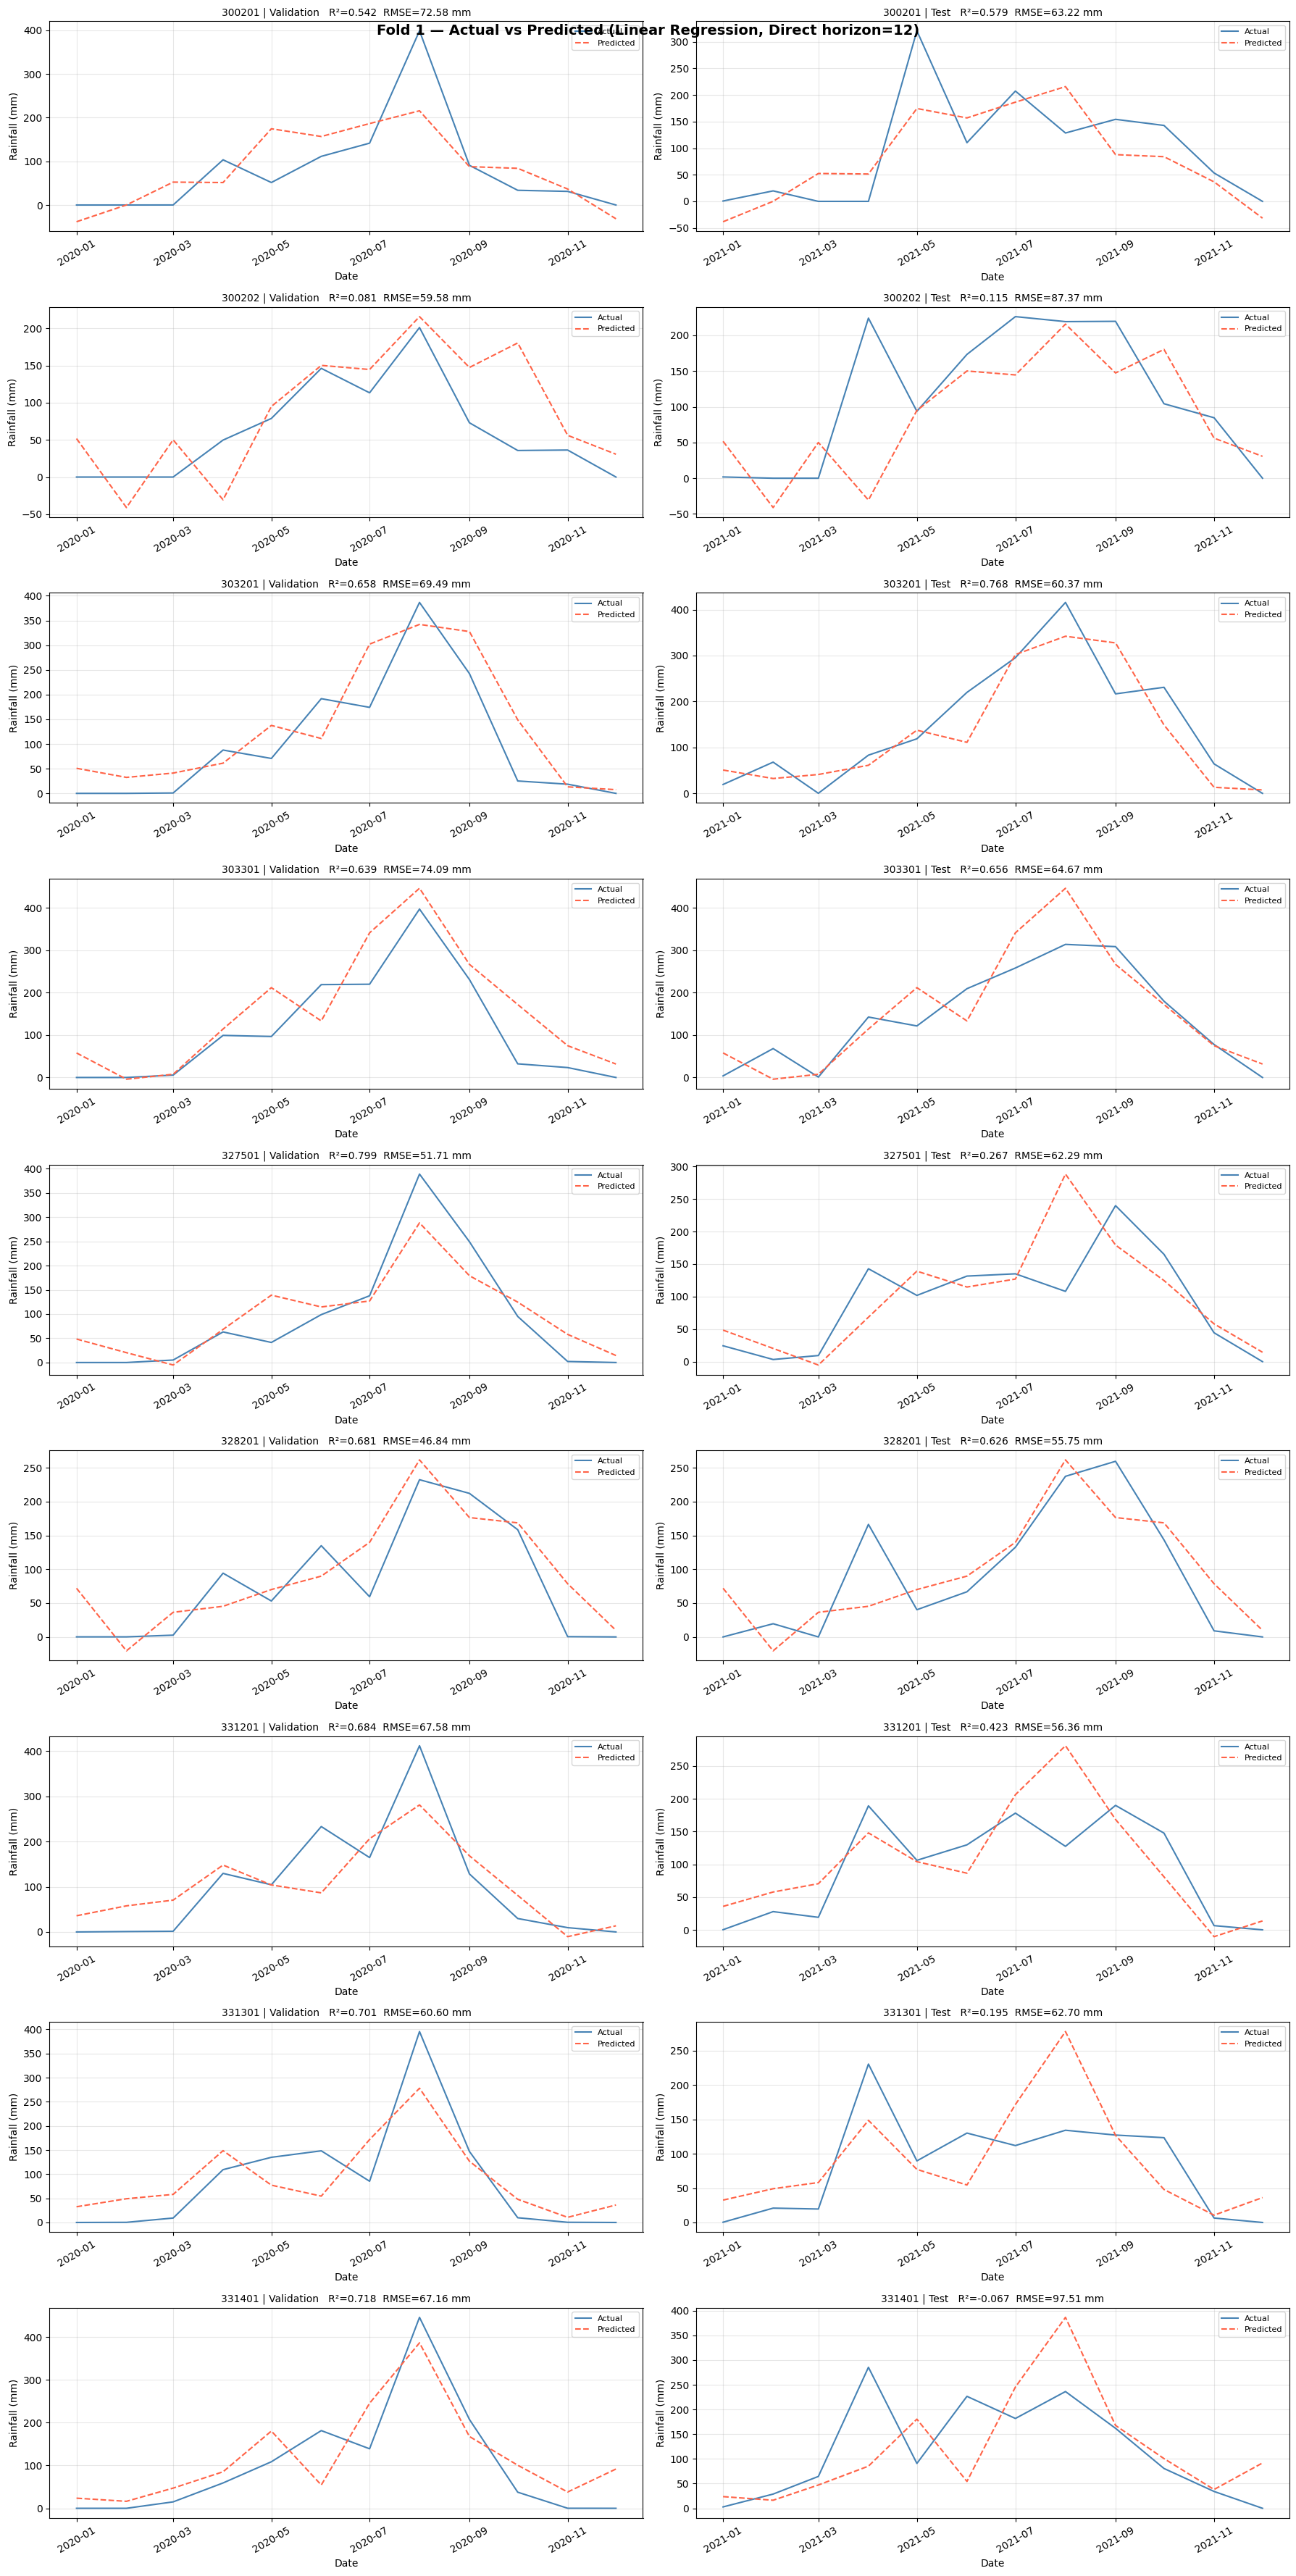

บันทึกกราฟ Fold 1 แล้ว ✓


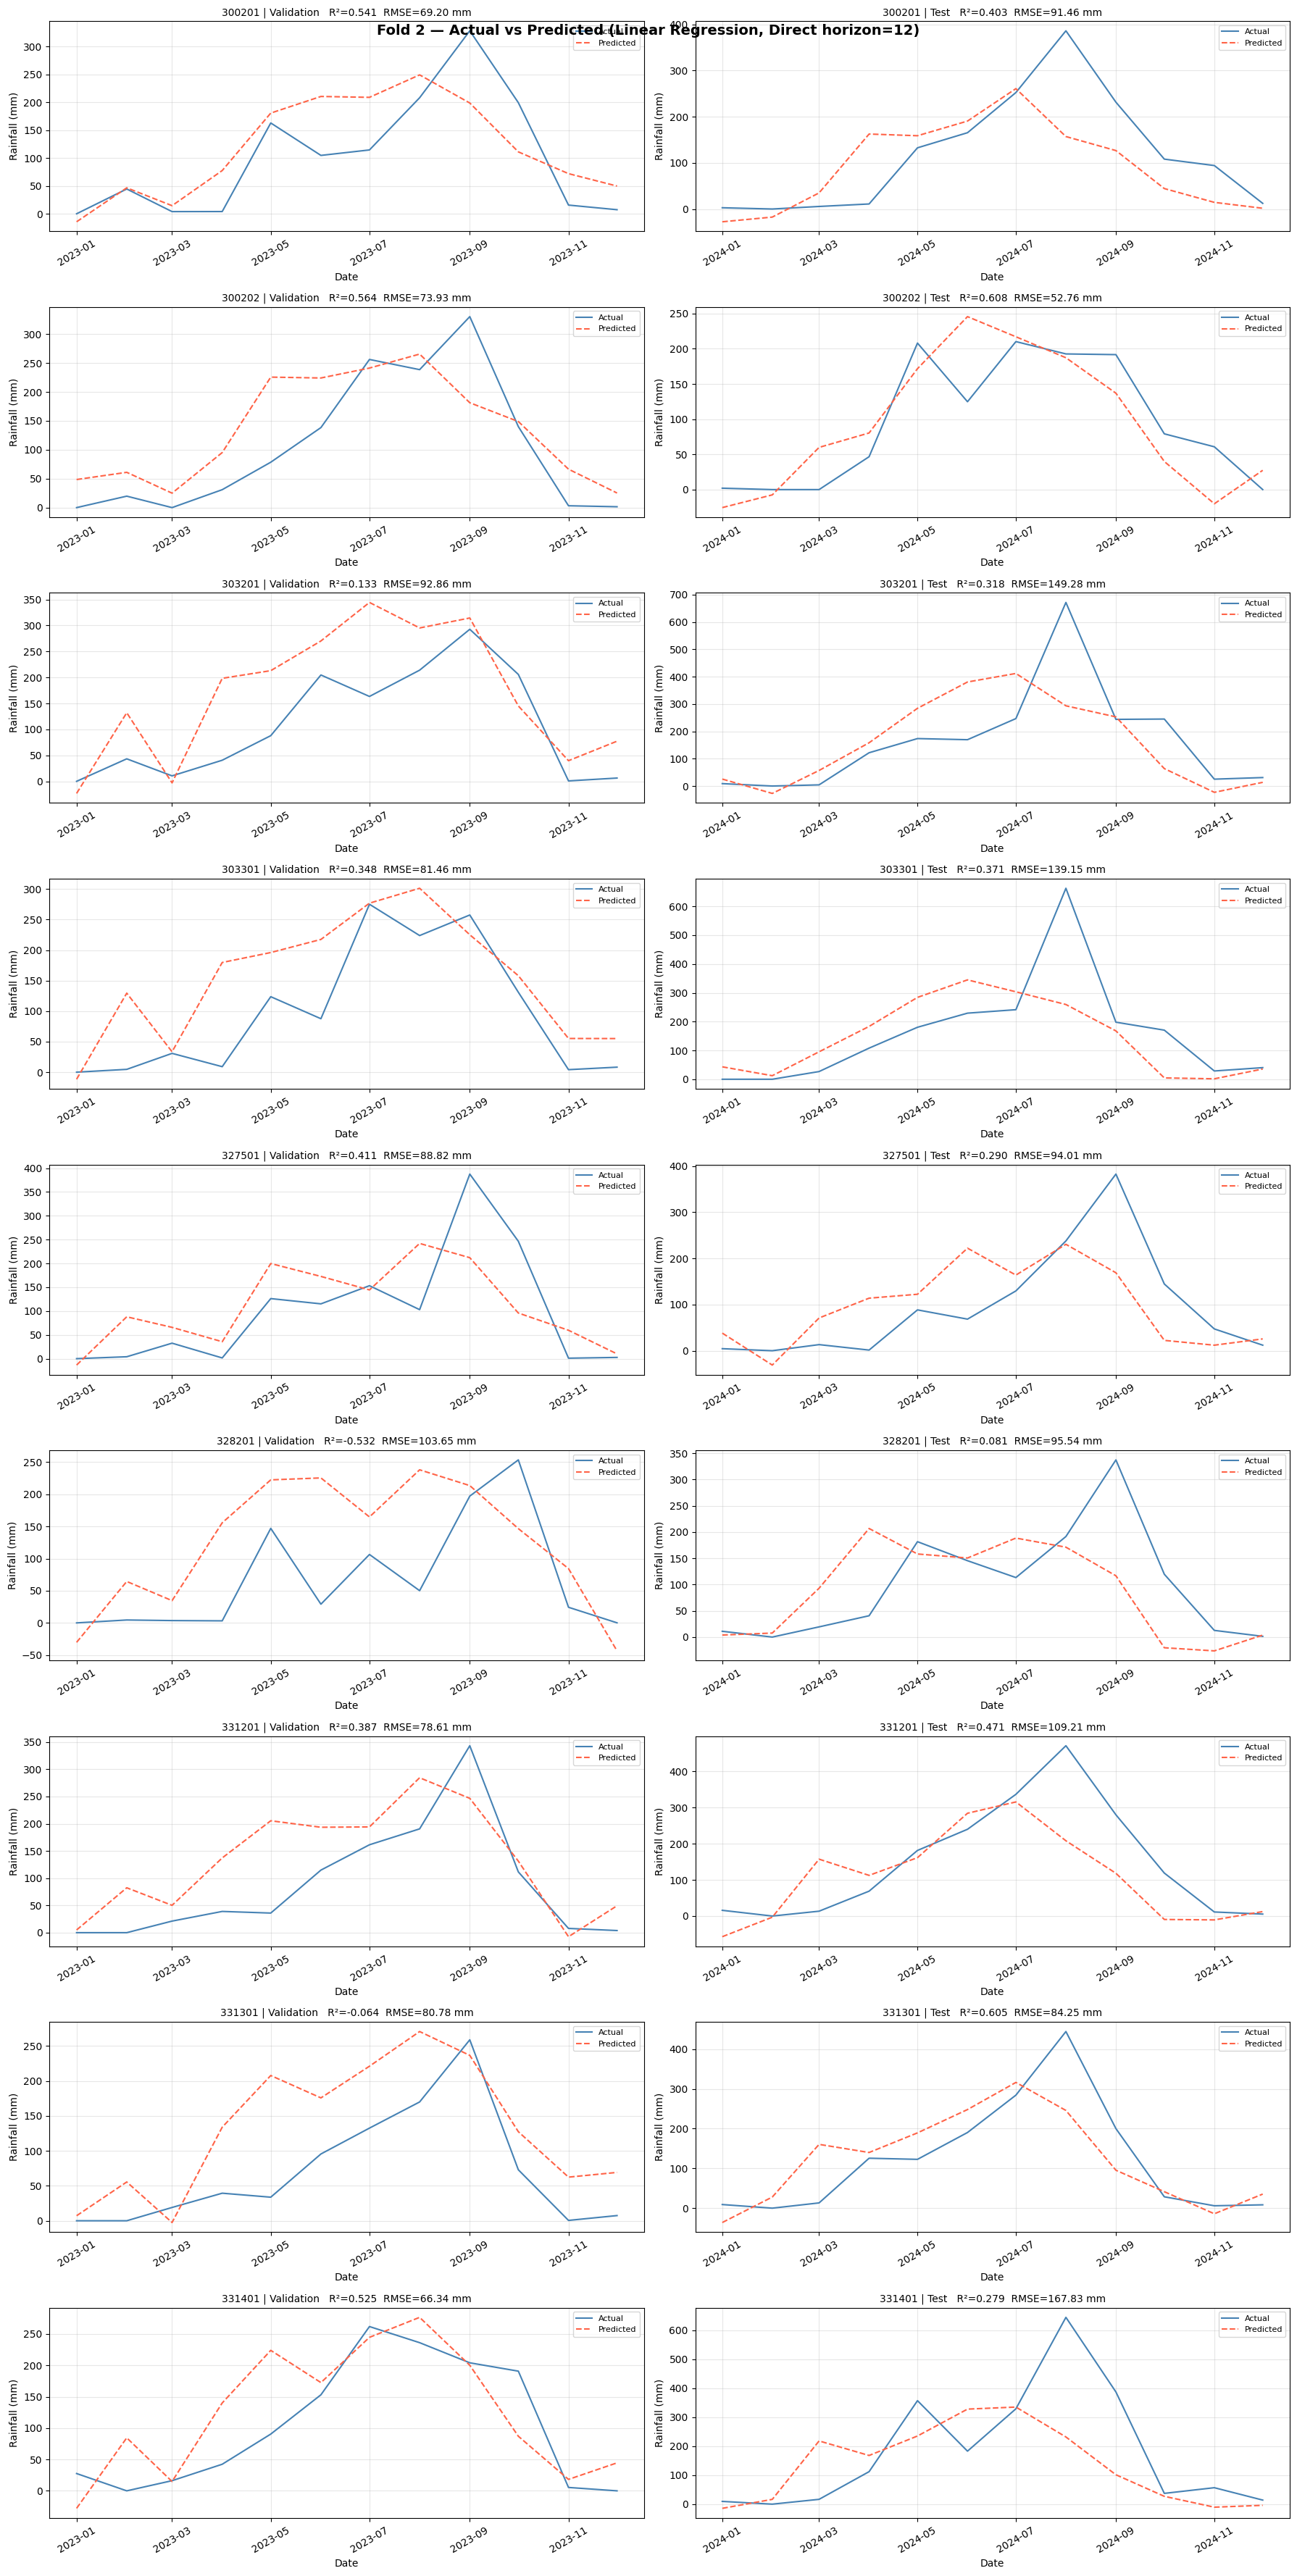

บันทึกกราฟ Fold 2 แล้ว ✓


In [187]:
# ============================================================
# STEP 4: Plot Actual vs Predicted
# ============================================================

for fold_idx in range(2):
    station_names = list(results[fold_idx].keys())
    n_stations = len(station_names)

    fig, axes = plt.subplots(
        nrows=n_stations, ncols=2,
        figsize=(18, 4 * n_stations),
        squeeze=False
    )
    fig.suptitle(f'Fold {fold_idx+1} — Actual vs Predicted (Linear Regression, Direct horizon=12)',
                 fontsize=14, fontweight='bold')

    for row, station_name in enumerate(station_names):
        res = results[fold_idx][station_name]

        for col, (split, dates, y_true, y_pred) in enumerate([
            ('Validation', res['val_dates'],  res['y_val'],  res['y_pred_val']),
            ('Test',       res['test_dates'], res['y_test'], res['y_pred_test']),
        ]):
            ax = axes[row][col]
            ax.plot(dates, y_true, label='Actual',    color='steelblue', linewidth=1.5)
            ax.plot(dates, y_pred, label='Predicted', color='tomato',
                    linewidth=1.5, linestyle='--')

            r2   = r2_score(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))

            ax.set_title(f'{station_name} | {split}   R²={r2:.3f}  RMSE={rmse:.2f} mm',
                         fontsize=10)
            ax.set_xlabel('Date')
            ax.set_ylabel('Rainfall (mm)')
            ax.legend(fontsize=8)
            ax.tick_params(axis='x', rotation=30)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/KKU3/LR_direct_fold{fold_idx+1}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"บันทึกกราฟ Fold {fold_idx+1} แล้ว ✓")

## ทำนายเพิ่มอีก12เดือน

In [188]:
# ============================================================
# STEP 5: พยากรณ์อนาคต 12 เดือน (ไม่มี actual ให้เทียบ)
# ใช้ข้อมูลล่าสุดทั้งหมดเป็น window → predict ออกไป
# Fold 1: window = 2020-01–2021-12 → predict 2022
# Fold 2: window = 2023-01–2024-12 → predict 2025
# ============================================================

future_results = {}

for fold_idx in range(2):
    future_results[fold_idx] = {}
    test_list = fold[fold_idx][1]

    for station_idx in cluster_station:
        station_name = node['Node'].iloc[station_idx]

        # window สุดท้ายของ test set (24 เดือนล่าสุด)
        last_window = test_list[station_idx].values[-window_size:]  # (24, 8)
        x_input = last_window.flatten().reshape(1, -1)              # (1, 192)

        # ดึง models จาก results ที่ train ไว้แล้ว
        models_h = results[fold_idx][station_name]['models']

        # predict 12 เดือนถัดไป
        y_pred_future = np.array([models_h[h].predict(x_input)[0] for h in range(horizon_lr)])

        # inverse transform กลับเป็น mm
        col_idx = station_idx
        dummy = np.zeros((len(y_pred_future), scaler_Y.n_features_in_))
        dummy[:, col_idx] = y_pred_future
        y_pred_future_mm = scaler_Y.inverse_transform(dummy)[:, col_idx]

        # สร้าง date range ของอนาคต
        last_date = test_list[station_idx].index[-1]
        future_dates = pd.date_range(
            start=last_date + relativedelta(months=1),
            periods=horizon_lr,
            freq='MS'
        )

        future_results[fold_idx][station_name] = {
            'y_pred_future' : y_pred_future_mm,
            'future_dates'  : future_dates,
        }

print("พยากรณ์อนาคตเสร็จสิ้น ✓")
for fold_idx in range(2):
    st = list(future_results[fold_idx].keys())[0]
    print(f"Fold {fold_idx+1} — ช่วงที่พยากรณ์: {future_results[fold_idx][st]['future_dates'][0].date()} → {future_results[fold_idx][st]['future_dates'][-1].date()}")

พยากรณ์อนาคตเสร็จสิ้น ✓
Fold 1 — ช่วงที่พยากรณ์: 2022-01-01 → 2022-12-01
Fold 2 — ช่วงที่พยากรณ์: 2025-01-01 → 2025-12-01


In [189]:
print(type(fold))
print(len(fold))

<class 'list'>
2


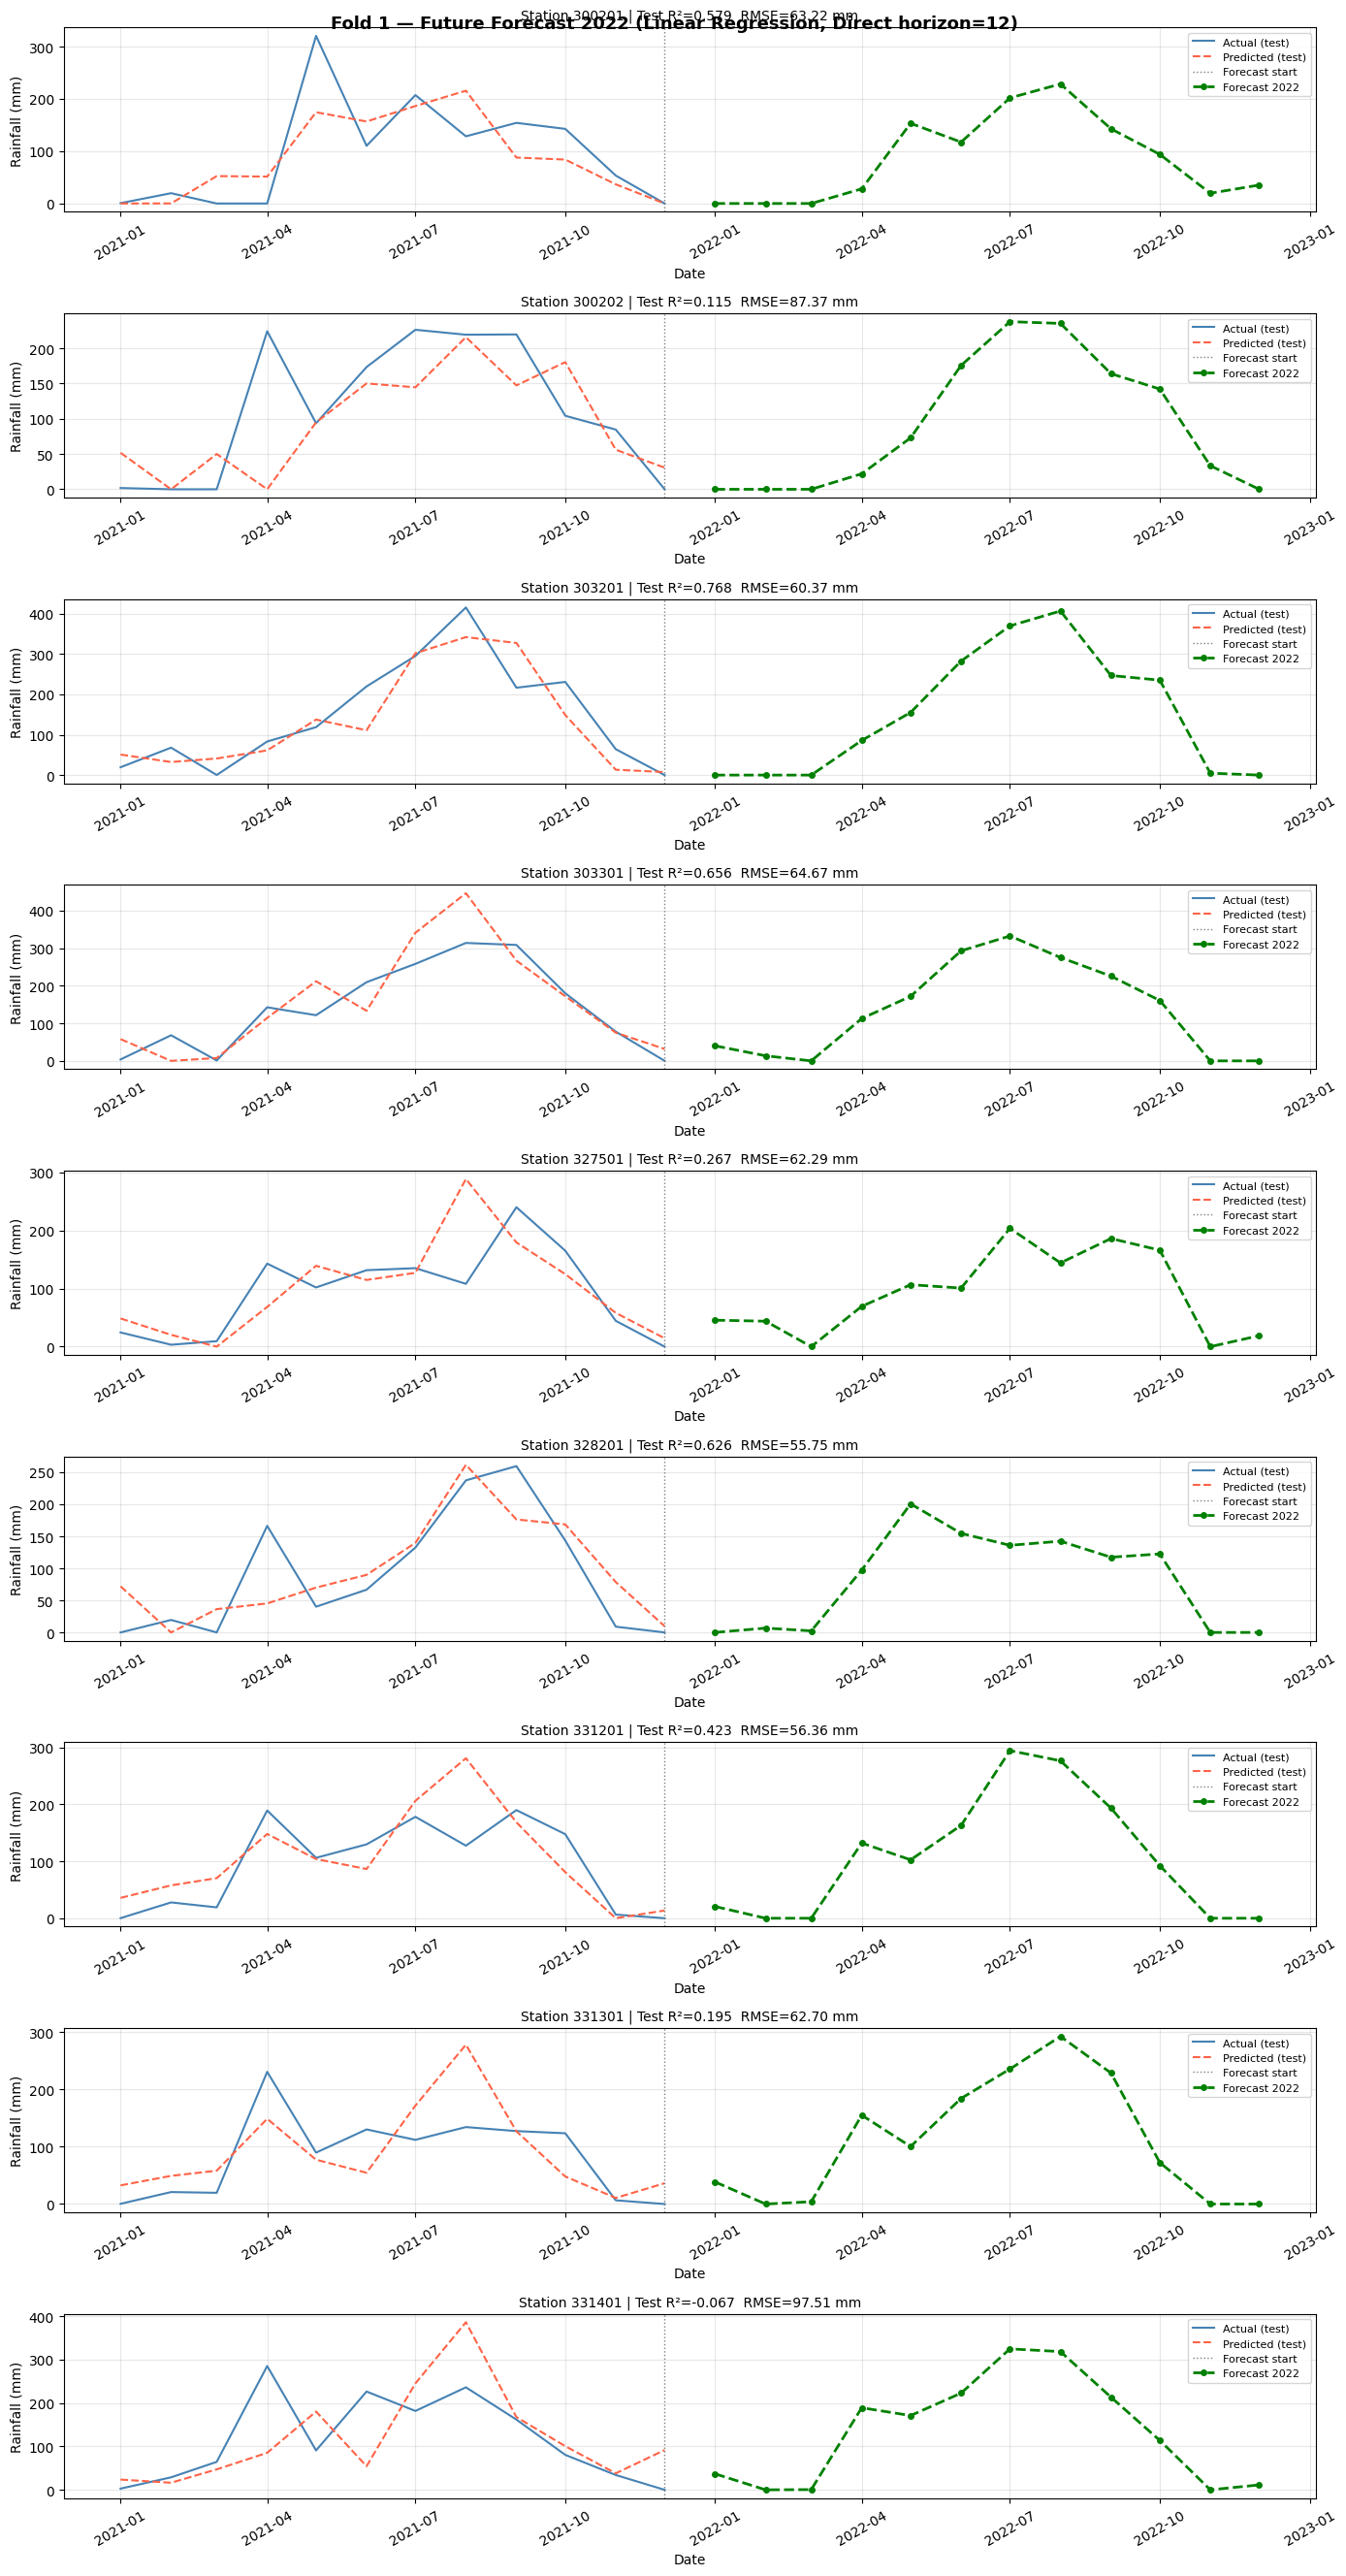

Fold 1 — Forecast 2022 saved ✓


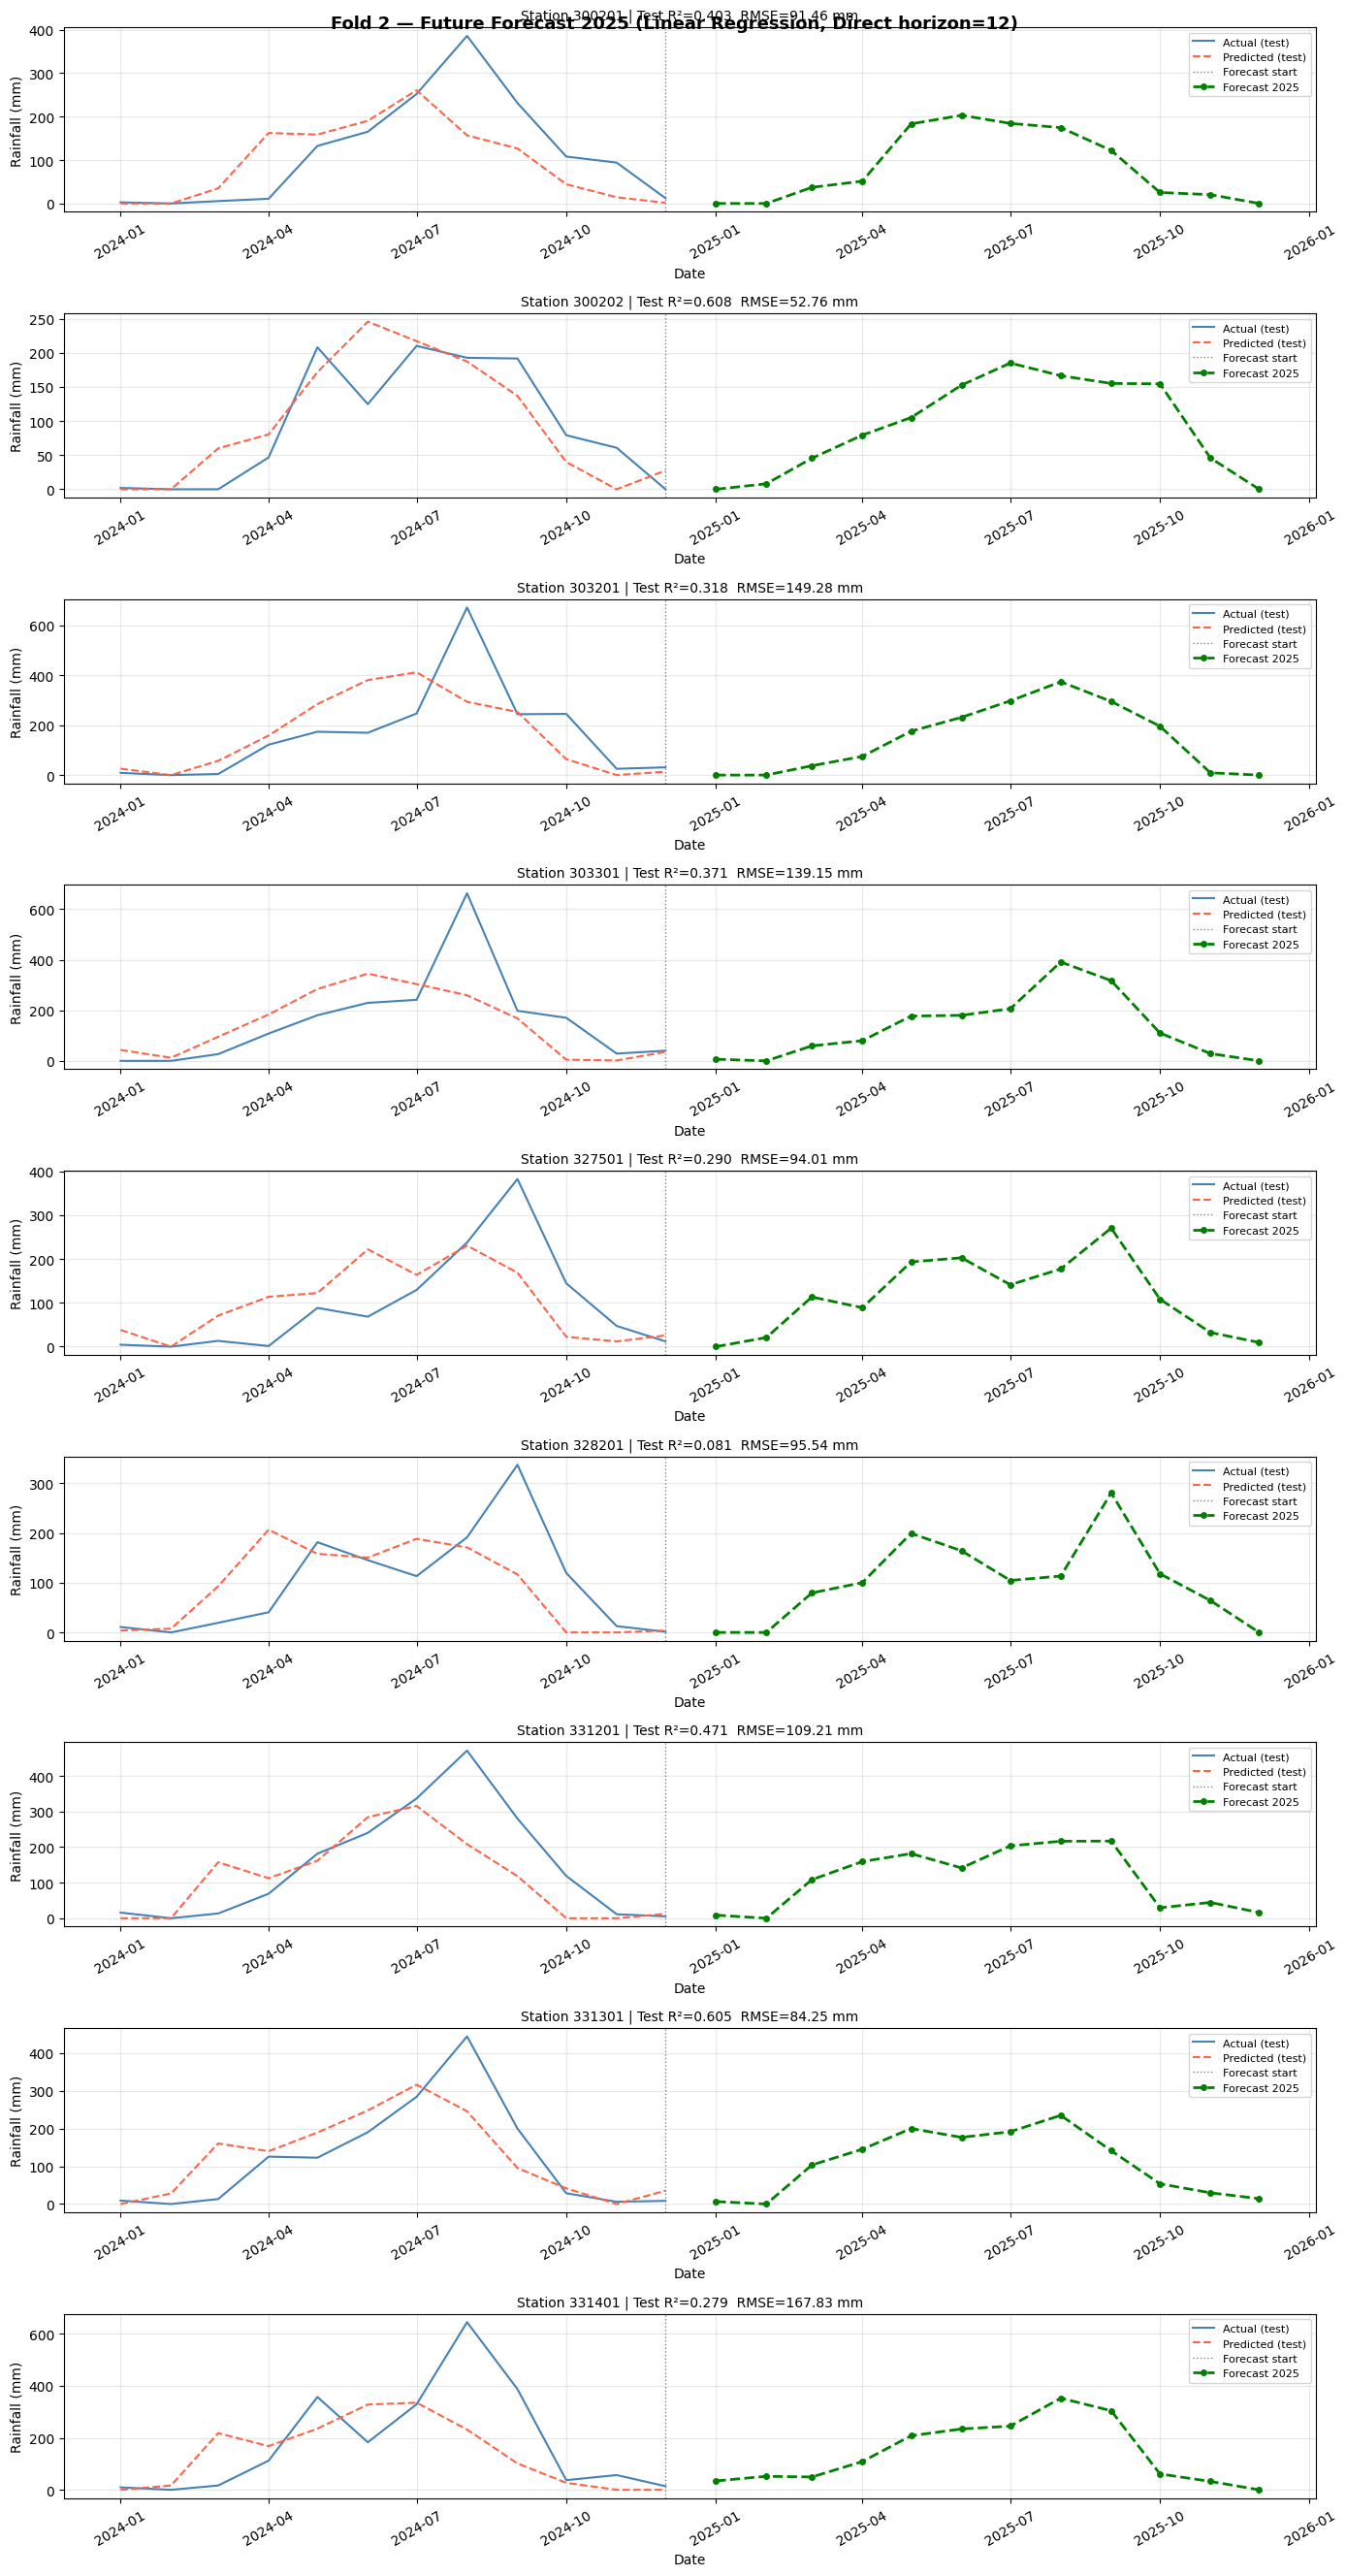

Fold 2 — Forecast 2025 saved ✓


In [190]:
# ============================================================
# STEP 5b: Plot Future Forecast
# ============================================================

for fold_idx in range(2):
    station_names = list(future_results[fold_idx].keys())
    n_stations = len(station_names)

    sample_dates = future_results[fold_idx][station_names[0]]['future_dates']
    future_year = sample_dates[0].year

    fig, axes = plt.subplots(
        nrows=n_stations, ncols=1,
        figsize=(14, 3 * n_stations),
        squeeze=False
    )
    fig.suptitle(f'Fold {fold_idx+1} — Future Forecast {future_year} (Linear Regression, Direct horizon=12)',
                 fontsize=13, fontweight='bold')

    for row, station_name in enumerate(station_names):
        ax = axes[row][0]
        res = results[fold_idx][station_name]
        fut = future_results[fold_idx][station_name]

        # clip ค่าติดลบเป็น 0
        y_pred_future_plot = np.maximum(fut['y_pred_future'], 0)
        y_pred_test_plot   = np.maximum(res['y_pred_test'],   0)

        # เส้น actual ช่วง test
        ax.plot(res['test_dates'], res['y_test'],
                label='Actual (test)', color='steelblue', linewidth=1.5)

        # เส้น predicted ช่วง test
        ax.plot(res['test_dates'], y_pred_test_plot,
                label='Predicted (test)', color='tomato',
                linewidth=1.5, linestyle='--')

        # เส้นแนวตั้งแบ่ง test vs future
        ax.axvline(res['test_dates'][-1], color='gray',
                   linewidth=1, linestyle=':', label='Forecast start')

        # เส้นพยากรณ์อนาคต
        ax.plot(fut['future_dates'], y_pred_future_plot,
                label=f'Forecast {future_year}', color='green',
                linewidth=2, linestyle='--', marker='o', markersize=4)

        r2   = r2_score(res['y_test'], res['y_pred_test'])
        rmse = np.sqrt(mean_squared_error(res['y_test'], res['y_pred_test']))

        ax.set_title(f'Station {station_name} | Test R²={r2:.3f}  RMSE={rmse:.2f} mm',
                     fontsize=10)
        ax.set_ylabel('Rainfall (mm)')
        ax.set_xlabel('Date')
        ax.legend(fontsize=8, loc='upper right')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/KKU3/LR_future_fold{fold_idx+1}_{future_year}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Fold {fold_idx+1} — Forecast {future_year} saved ✓")

In [191]:
# ============================================================
# เปรียบเทียบ Forecast 2022 (Fold 1) กับ Actual 2022
# ============================================================

compare_rows = []

for station_idx in cluster_station:
    station_name = node['Node'].iloc[station_idx]

    # ดึงข้อมูลจริงปี 2022 จาก Fold 2 test (for comparison with Fold 1's 2022 forecast)
    test_fold2 = fold[1][1][station_idx] # test_list is fold[idx][1]
    actual_2022 = test_fold2[
        (test_fold2.index.year == 2022)
    ].iloc[:, -1].values  # rainfall column

    # inverse transform
    col_idx = station_idx
    dummy = np.zeros((len(actual_2022), scaler_Y.n_features_in_))
    dummy[:, col_idx] = actual_2022
    actual_2022_mm = scaler_Y.inverse_transform(dummy)[:, col_idx]

    # ค่าพยากรณ์ 2022 จาก Fold 1
    forecast_2022 = future_results[0][station_name]['y_pred_future']

    # คำนวณ metrics
    n = min(len(actual_2022_mm), len(forecast_2022))
    rmse = np.sqrt(mean_squared_error(actual_2022_mm[:n], forecast_2022[:n]))
    mae  = mean_absolute_error(actual_2022_mm[:n], forecast_2022[:n])
    r2   = r2_score(actual_2022_mm[:n], forecast_2022[:n])
    nse  = nse_score(actual_2022_mm[:n], forecast_2022[:n])

    compare_rows.append({
        'Station' : station_name,
        'RMSE'    : round(rmse, 4),
        'MAE'     : round(mae,  4),
        'R²'      : round(r2,   4),
        'NSE'     : round(nse,  4),
    })

compare_df = pd.DataFrame(compare_rows)
print("=== Forecast 2022 (Fold 1) vs Actual 2022 ===")
print(compare_df.to_string(index=False))
print("\n=== ค่าเฉลี่ย ===")
print(compare_df[['RMSE','MAE','R²','NSE']].mean().round(4))

=== Forecast 2022 (Fold 1) vs Actual 2022 ===
 Station     RMSE     MAE     R²    NSE
  300201  68.7609 54.9279 0.6579 0.6579
  300202 102.4184 82.0067 0.1935 0.1935
  303201  67.1890 58.9192 0.7640 0.7640
  303301  95.6897 70.4685 0.6730 0.6730
  327501 127.0345 88.0956 0.1477 0.1477
  328201  81.3944 55.5102 0.3569 0.3569
  331201  77.3212 56.7092 0.2218 0.2218
  331301  63.5565 46.9560 0.4938 0.4938
  331401  91.4089 68.6921 0.3215 0.3215

=== ค่าเฉลี่ย ===
RMSE    86.0859
MAE     64.6984
R²       0.4256
NSE      0.4256
dtype: float64


In [192]:
st = cluster_station[0]
station_name = node['Node'].iloc[st]
train_fold2_df = fold[1][0][st]

# ตรวจ actual
mask = train_fold2_df.index.year == 2022
print("actual rows:", mask.sum())
print("actual values (normalized):", train_fold2_df.loc[mask].iloc[:, -1].values)
print("actual dates:", train_fold2_df.loc[mask].index)
print()

# inverse transform
actual_norm = train_fold2_df.loc[mask].iloc[:, -1].values
dummy = np.zeros((len(actual_norm), scaler_Y.n_features_in_))
dummy[:, st] = actual_norm
actual_mm = scaler_Y.inverse_transform(dummy)[:, st]
print("actual mm:", actual_mm)
print()

# forecast
print("forecast dates:", future_results[0][station_name]['future_dates'])
print("forecast mm:", future_results[0][station_name]['y_pred_future'])

actual rows: 1
actual values (normalized): [-0.90477645]
actual dates: DatetimeIndex(['2022-01-01'], dtype='datetime64[ns]', name='DATE', freq=None)

actual mm: [11.9]

forecast dates: DatetimeIndex(['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01'],
              dtype='datetime64[ns]', freq='MS')
forecast mm: [-29.25174153 -44.10625252  -7.04984206  27.9919571  153.31034307
 117.43606282 201.90335596 228.55636996 142.83871401  93.93447986
  19.57303547  35.25573191]


In [193]:
# ตรวจสอบว่า test fold 2 มีปี 2022 ไหม
st = cluster_station[0]
test_fold2_df = fold[1][1][st]
print("ปีใน test fold 2:", test_fold2_df.index.year.unique())
print("ช่วง:", test_fold2_df.index[0], "→", test_fold2_df.index[-1])

ปีใน test fold 2: Index([2022, 2023, 2024], dtype='int32', name='DATE')
ช่วง: 2022-01-01 00:00:00 → 2024-12-01 00:00:00


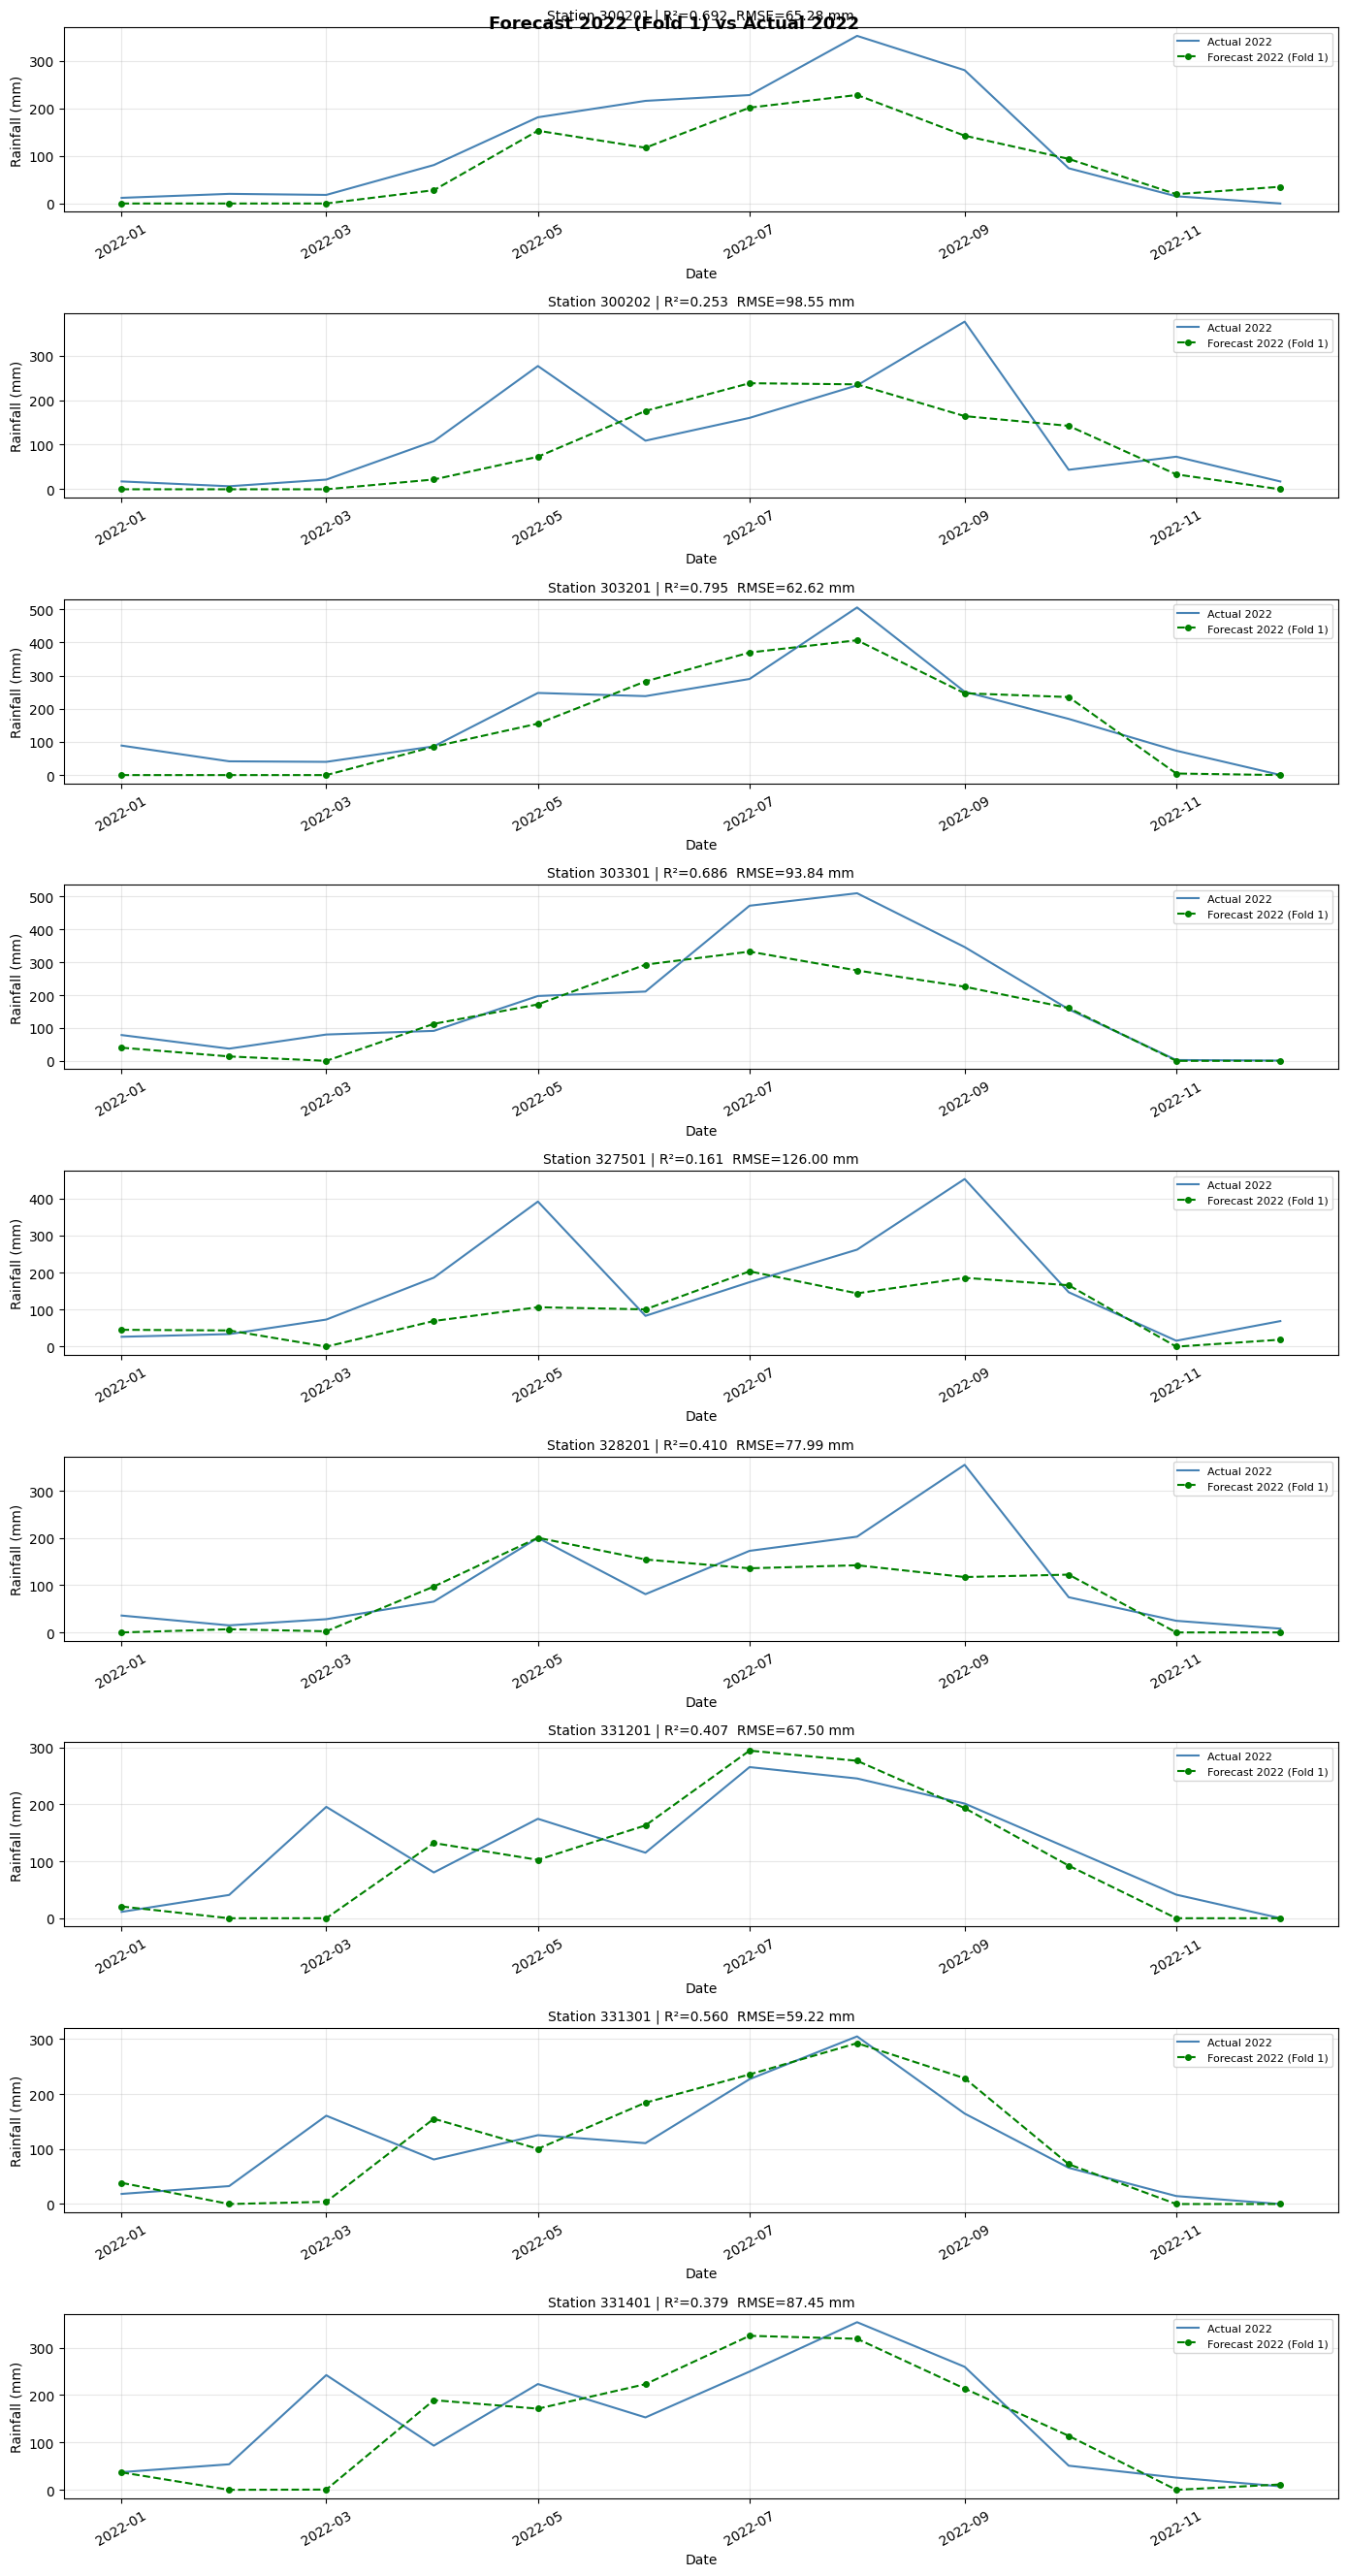

บันทึกกราฟแล้ว ✓


In [194]:
fig, axes = plt.subplots(
    nrows=len(cluster_station), ncols=1,
    figsize=(14, 3 * len(cluster_station)),
    squeeze=False
)
fig.suptitle('Forecast 2022 (Fold 1) vs Actual 2022',
             fontsize=13, fontweight='bold')

for row, station_idx in enumerate(cluster_station):
    station_name = node['Node'].iloc[station_idx]
    ax = axes[row][0]

    # ดึง actual 2022 จาก test fold 2
    test_fold2_df = fold[1][1][station_idx]
    mask = test_fold2_df.index.year == 2022
    actual_2022_norm = test_fold2_df.loc[mask].iloc[:, -1].values
    dates_2022 = test_fold2_df.loc[mask].index

    # inverse transform
    dummy = np.zeros((len(actual_2022_norm), scaler_Y.n_features_in_))
    dummy[:, station_idx] = actual_2022_norm
    actual_2022_mm = scaler_Y.inverse_transform(dummy)[:, station_idx]

    # forecast 2022 — clip ค่าติดลบ
    forecast_2022  = np.maximum(future_results[0][station_name]['y_pred_future'], 0)
    forecast_dates = future_results[0][station_name]['future_dates']

    n    = min(len(actual_2022_mm), len(forecast_2022))
    rmse = np.sqrt(mean_squared_error(actual_2022_mm[:n], forecast_2022[:n]))
    r2   = r2_score(actual_2022_mm[:n], forecast_2022[:n])

    ax.plot(dates_2022[:n], actual_2022_mm[:n],
            label='Actual 2022', color='steelblue', linewidth=1.5)
    ax.plot(forecast_dates[:n], forecast_2022[:n],
            label='Forecast 2022 (Fold 1)', color='green',
            linewidth=1.5, linestyle='--', marker='o', markersize=4)

    ax.set_title(f'Station {station_name} | R²={r2:.3f}  RMSE={rmse:.2f} mm',
                 fontsize=10)
    ax.set_ylabel('Rainfall (mm)')
    ax.set_xlabel('Date')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/KKU3/LR_forecast2022_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("บันทึกกราฟแล้ว ✓")